In [1]:
# 🚀 Load Data for Model Building
# Load meteorological data (X features) and 2D wave spectra (Y targets)

import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

print("🚀 Loading data for model building...")

# =============================================================================
# 📊 Load Meteorological DataFrames (X Features)
# =============================================================================

print("\n📊 Loading meteorological dataframes...")

# Define dataframes directory path
dataframes_dir = Path('../data/dataframes')

if not dataframes_dir.exists():
    print(f"❌ Directory not found: {dataframes_dir}")
    print("   Make sure to run the data engineering pipeline first!")
else:
    print(f"📁 Loading from: {dataframes_dir.absolute()}")
    
    # Find all met pickle files
    met_pkl_files = list(dataframes_dir.glob("met_*.pkl"))
    
    if not met_pkl_files:
        print("❌ No meteorological pickle files found!")
    else:
        print(f"🎯 Found {len(met_pkl_files)} meteorological files")
        
        # Load each met dataframe
        loaded_met_count = 0
        failed_met_count = 0
        met_size_mb = 0
        loaded_met_dfs = []
        
        for pkl_file in sorted(met_pkl_files):
            try:
                # Extract dataframe name from filename
                df_name = pkl_file.stem
                
                # Load dataframe from pickle
                df = pd.read_pickle(pkl_file)
                
                # Create variable in global namespace
                globals()[df_name] = df
                
                # Get file size
                file_size_mb = pkl_file.stat().st_size / (1024 * 1024)
                met_size_mb += file_size_mb
                
                loaded_met_count += 1
                loaded_met_dfs.append(df_name)
                
                print(f"  ✅ {df_name}: {df.shape} ({file_size_mb:.2f} MB)")
                
            except Exception as e:
                failed_met_count += 1
                print(f"  ❌ {pkl_file.name}: Error - {str(e)}")
        
        print(f"\n✅ Meteorological data loading completed!")
        print(f"   ✅ Successfully loaded: {loaded_met_count}")
        print(f"   ❌ Failed to load: {failed_met_count}")
        print(f"   💽 Total size: {met_size_mb:.2f} MB")

# =============================================================================
# 🌊 Load 2D Wave Spectrum Y DataFrames (Y Targets)
# =============================================================================

print("\n🌊 Loading 2D wave spectrum Y variables...")

# Check Y spectra directory
y_spectra_dir = Path('../data/Y_spectra')

if not y_spectra_dir.exists():
    print(f"❌ Y spectra directory not found: {y_spectra_dir}")
    print("   Run Y_prep.ipynb first to create 2D wave spectra!")
else:
    print(f"📁 Loading from: {y_spectra_dir.absolute()}")
    
    # Find all Y pickle files
    y_pkl_files = list(y_spectra_dir.glob("Y_*.pkl"))
    
    if not y_pkl_files:
        print("❌ No Y spectrum pickle files found!")
    else:
        print(f"🎯 Found {len(y_pkl_files)} Y spectrum files")
        
        # Load each Y variable
        loaded_y_count = 0
        failed_y_count = 0
        y_size_mb = 0
        loaded_y_dfs = []
        
        for pkl_file in sorted(y_pkl_files):
            try:
                # Extract variable name from filename
                y_name = pkl_file.stem  # Remove .pkl extension
                
                # Load DataFrame
                y_df = pd.read_pickle(pkl_file)
                
                # Store in global namespace
                globals()[y_name] = y_df
                
                # Get file size
                file_size_mb = pkl_file.stat().st_size / (1024 * 1024)
                y_size_mb += file_size_mb
                
                loaded_y_dfs.append(y_name)
                loaded_y_count += 1
                
                print(f"  ✅ {y_name}: {y_df.shape} ({file_size_mb:.2f} MB)")
                
            except Exception as e:
                failed_y_count += 1
                print(f"  ❌ {pkl_file.name}: Error - {str(e)}")
        
        print(f"\n✅ Y spectrum data loading completed!")
        print(f"   ✅ Successfully loaded: {loaded_y_count}")
        print(f"   ❌ Failed to load: {failed_y_count}")
        print(f"   💽 Total size: {y_size_mb:.2f} MB")

print("\n✅ All data loaded successfully! Ready for model building.")

🚀 Loading data for model building...

📊 Loading meteorological dataframes...
📁 Loading from: d:\projects\FYP-OCNWVS\notebooks\..\data\dataframes
🎯 Found 21 meteorological files
  ✅ met_41008_2006: (739, 7) (0.04 MB)
  ✅ met_41008_2007: (8650, 7) (0.50 MB)
  ✅ met_41008_2008: (8650, 7) (0.50 MB)
  ✅ met_41008_2009: (3250, 7) (0.19 MB)
  ✅ met_41008_2013: (8041, 7) (0.47 MB)
  ✅ met_41008_2014: (8406, 7) (0.49 MB)
  ✅ met_41008_2015: (8644, 7) (0.50 MB)
  ✅ met_41008_2016: (6151, 7) (0.36 MB)
  ✅ met_41008_2017: (8583, 7) (0.50 MB)
  ✅ met_41008_2018: (8613, 7) (0.50 MB)
  ✅ met_41008_2019: (8586, 7) (0.50 MB)
  ✅ met_41008_2020: (8580, 7) (0.50 MB)
  ✅ met_41008_2021: (8490, 7) (0.49 MB)
  ✅ met_41008_2022: (8655, 7) (0.50 MB)
  ✅ met_41008_2023: (5322, 7) (0.31 MB)
  ✅ met_41008_2024: (1825, 7) (0.11 MB)
  ✅ met_41008_2025: (1791, 7) (0.10 MB)
  ✅ met_51028_2005: (6787, 7) (0.40 MB)
  ✅ met_51028_2006: (7073, 7) (0.41 MB)
  ✅ met_51028_2007: (2962, 7) (0.17 MB)
  ✅ met_51028_2008: (250

In [2]:
# 🔧 Process X Features (Meteorological Data)
# Convert directional variables to sin/cos and standardize

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("🔧 Processing X features (meteorological data)...")

# =============================================================================
# 🔄 Process All Meteorological DataFrames  
# =============================================================================

# Find all met variables
met_variables = [name for name in globals().keys() if name.startswith('met_') and isinstance(globals()[name], pd.DataFrame)]

if not met_variables:
    print("❌ No meteorological dataframes found!")
else:
    print(f"\n🎯 Processing {len(met_variables)} meteorological datasets...")
    
    # Storage for processed data
    X_processed = {}
    feature_names = None
    
    # Process all datasets (convert directions, handle missing) WITHOUT scaling
    print(f"\n📊 Converting directions and handling missing values...")
    
    for met_name in sorted(met_variables):
        print(f"  📍 Processing {met_name}...")
        
        met_df = globals()[met_name]
        
        # Create copy to avoid modifying original
        df = met_df.copy()
        
        # Remove timekey column
        if 'timekey' in df.columns:
            df = df.drop('timekey', axis=1)
        
        print(f"    Original columns: {list(df.columns)}")
        
        # Convert directional variables to sin/cos
        directional_cols = ['WDIR', 'MWD']  # Wind direction, Mean Wave Direction
        
        for col in directional_cols:
            if col in df.columns:
                # Convert degrees to radians
                angles_rad = np.deg2rad(df[col])
                
                # Create sin/cos components
                df[f'{col}_sin'] = np.sin(angles_rad)
                df[f'{col}_cos'] = np.cos(angles_rad)
                
                # Drop original angle column
                df = df.drop(col, axis=1)
                print(f"    ✅ Converted {col} → {col}_sin, {col}_cos")
        
        # Expected final columns: [WSPD, WVHT, DPD, APD, WDIR_sin, WDIR_cos, MWD_sin, MWD_cos]
        final_cols = list(df.columns)
        print(f"    Final columns ({len(final_cols)}): {final_cols}")
        
        # Get feature names (should be same for all datasets)
        if feature_names is None:
            feature_names = final_cols
        
        # Convert to numpy array (unscaled)
        X_unscaled = df.values
        
        # Store UNSCALED processed data
        X_processed[met_name] = X_unscaled
        
        print(f"    ✅ Processed shape: {X_unscaled.shape} (UNSCALED)")
    
    print(f"\n✅ Meteorological data processing completed!")
    print(f"   📊 Processed datasets: {len(X_processed)}")
    print(f"   🔧 Feature names: {feature_names}")
    print(f"   📏 Data is UNSCALED - scaling will be done after train-test split")
    
    # Show summary by station
    stations = {}
    for met_name in X_processed.keys():
        parts = met_name.split('_')
        if len(parts) >= 3:
            station = parts[1]
            year = parts[2]
            if station not in stations:
                stations[station] = []
            stations[station].append((year, X_processed[met_name].shape))
    
    print(f"\n📍 X Features by Station:")
    for station, data in sorted(stations.items()):
        years = [item[0] for item in data]
        total_samples = sum(item[1][0] for item in data)
        n_features = data[0][1][1] if data else 0
        print(f"   Station {station}: {len(data)} years ({', '.join(sorted(years))}) - {total_samples:,} samples × {n_features} features")

print(f"\n🎯 X features ready for alignment and train-test split!")
print(f"📋 Expected 8 features: [WSPD, WVHT, DPD, APD, WDIR_sin, WDIR_cos, MWD_sin, MWD_cos]")

print(f"\n🎯 X features ready for model training!")

🔧 Processing X features (meteorological data)...

🎯 Processing 21 meteorological datasets...

📊 Converting directions and handling missing values...
  📍 Processing met_41008_2006...
    Original columns: ['WDIR', 'WSPD', 'WVHT', 'DPD', 'APD', 'MWD']
    ✅ Converted WDIR → WDIR_sin, WDIR_cos
    ✅ Converted MWD → MWD_sin, MWD_cos
    Final columns (8): ['WSPD', 'WVHT', 'DPD', 'APD', 'WDIR_sin', 'WDIR_cos', 'MWD_sin', 'MWD_cos']
    ✅ Processed shape: (739, 8) (UNSCALED)
  📍 Processing met_41008_2007...
    Original columns: ['WDIR', 'WSPD', 'WVHT', 'DPD', 'APD', 'MWD']
    ✅ Converted WDIR → WDIR_sin, WDIR_cos
    ✅ Converted MWD → MWD_sin, MWD_cos
    Final columns (8): ['WSPD', 'WVHT', 'DPD', 'APD', 'WDIR_sin', 'WDIR_cos', 'MWD_sin', 'MWD_cos']
    ✅ Processed shape: (8650, 8) (UNSCALED)
  📍 Processing met_41008_2008...
    Original columns: ['WDIR', 'WSPD', 'WVHT', 'DPD', 'APD', 'MWD']
    ✅ Converted WDIR → WDIR_sin, WDIR_cos
    ✅ Converted MWD → MWD_sin, MWD_cos
    Final columns 

In [3]:
# 🌊 Process Y Targets (2D Wave Spectrum Data)
# Apply log transform: Y → log(Y+ε)

import pandas as pd
import numpy as np

print("🌊 Processing Y targets (2D wave spectrum data)...")

# =============================================================================
# 📊 Log Transform Parameters 
# =============================================================================

# Small epsilon to avoid log(0)
epsilon = 1e-6

print(f"🔬 Transform pipeline: Y → log(Y + ε), where ε = {epsilon}")

# =============================================================================
# 🔄 Process All Y DataFrames
# =============================================================================

# Find all Y variables
y_variables = [name for name in globals().keys() if name.startswith('Y_') and isinstance(globals()[name], pd.DataFrame)]

if not y_variables:
    print("❌ No Y dataframes found!")
else:
    print(f"\n🎯 Processing {len(y_variables)} Y spectrum datasets...")
    
    # Storage for processed data  
    Y_processed = {}
    Y_timekeys = {}
    Y_means = {}  # Store means for denormalization
    Y_stds = {}   # Store std for denormalization
    spectrum_columns = None
    
    # Process each Y dataframe
    for y_name in sorted(y_variables):
        print(f"\n📍 Processing {y_name}...")
        
        y_df = globals()[y_name]
        
        print(f"  Original shape: {y_df.shape}")
        
        # Extract timekey for alignment with X data
        if 'timekey' in y_df.columns:
            timekeys = y_df['timekey'].values
            # Remove timekey column for spectrum processing
            spectrum_df = y_df.drop('timekey', axis=1)
        else:
            print("  ⚠️ No timekey column found!")
            timekeys = None
            spectrum_df = y_df.copy()
        
        # Get spectrum column names
        if spectrum_columns is None:
            spectrum_columns = list(spectrum_df.columns)
            
        print(f"  Spectrum shape: {spectrum_df.shape}")
        print(f"  Spectrum columns: {len(spectrum_columns)} (f×θ combinations)")
        print(f"  Sample columns: {spectrum_columns[:5]}...")
        
        # Convert to numpy array Y.shape → (time, 1692)
        Y = spectrum_df.values
        
        # Check for negative values (should not exist in energy spectra)
        negative_count = (Y < 0).sum()
        if negative_count > 0:
            print(f"  ⚠️ Found {negative_count} negative values - setting to zero")
            Y = np.maximum(Y, 0)
        
        # Check data statistics before transform
        zero_count = (Y == 0).sum()
        total_count = Y.size
        nonzero_min = Y[Y > 0].min() if (Y > 0).any() else 0
        
        print(f"  📊 Pre-transform stats:")
        print(f"     Zero values: {zero_count:,}/{total_count:,} ({100*zero_count/total_count:.1f}%)")
        print(f"     Non-zero min: {nonzero_min:.2e}")
        print(f"     Max value: {Y.max():.2e}")
        
        # Apply log transform: Y_log = log(Y + ε)
        Y_log = np.log(Y + epsilon)
        
        print(f"  🔬 Log-transform stats:")
        print(f"     Min: {Y_log.min():.6f}")
        print(f"     Max: {Y_log.max():.6f}")
        print(f"     Mean: {Y_log.mean():.6f}")
        print(f"     Std: {Y_log.std():.6f}")
        
        # Store log-transformed data (NO standardization)
        Y_processed[y_name] = Y_log
        Y_timekeys[y_name] = timekeys
        
        print(f"  ✅ Y_log ready: {Y_log.shape}")
    
    print(f"\n✅ Y spectrum data processing completed!")
    print(f"   📊 Processed datasets: {len(Y_processed)}")
    print(f"   🔬 Transform: Y → log(Y + {epsilon}) ONLY")
    print(f"   📋 Spectrum features: {len(spectrum_columns) if spectrum_columns else 0}")
    print(f"   📊 Y_log values in natural log scale")
    
    # Show summary by station
    stations = {}
    for y_name in Y_processed.keys():
        parts = y_name.split('_')
        if len(parts) >= 3:
            station = parts[1]
            year = parts[2]
            if station not in stations:
                stations[station] = []
            stations[station].append((year, Y_processed[y_name].shape))
    
    print(f"\n📍 Y Targets by Station:")
    for station, data in sorted(stations.items()):
        years = [item[0] for item in data]
        total_samples = sum(item[1][0] for item in data)
        n_features = data[0][1][1] if data else 0
        print(f"   Station {station}: {len(data)} years ({', '.join(sorted(years))}) - {total_samples:,} samples × {n_features} features")

print(f"\n🎯 Y_norm arrays ready for train-test split!")
print(f"   Expected usage: Y_train = Y_norm[train_indices], Y_test = Y_norm[test_indices]")
print(f"   Y statistics (Y_means, Y_stds) stored for denormalization during evaluation")

🌊 Processing Y targets (2D wave spectrum data)...
🔬 Transform pipeline: Y → log(Y + ε), where ε = 1e-06

🎯 Processing 21 Y spectrum datasets...

📍 Processing Y_41008_2006...
  Original shape: (739, 1693)
  Spectrum shape: (739, 1692)
  Spectrum columns: 1692 (f×θ combinations)
  Sample columns: ['f.0200_dir000', 'f.0200_dir010', 'f.0200_dir020', 'f.0200_dir030', 'f.0200_dir040']...
  📊 Pre-transform stats:
     Zero values: 575,848/1,250,388 (46.1%)
     Non-zero min: 5.38e-11
     Max value: 5.57e-01
  🔬 Log-transform stats:
     Min: -13.815511
     Max: -0.585838
     Mean: -9.694050
     Std: 4.058849
  ✅ Y_log ready: (739, 1692)

📍 Processing Y_41008_2007...
  Original shape: (8650, 1693)
  Spectrum shape: (8650, 1692)
  Spectrum columns: 1692 (f×θ combinations)
  Sample columns: ['f.0200_dir000', 'f.0200_dir010', 'f.0200_dir020', 'f.0200_dir030', 'f.0200_dir040']...
  📊 Pre-transform stats:
     Zero values: 6,733,836/14,635,800 (46.0%)
     Non-zero min: 4.60e-20
     Max value:

In [25]:
# 🔄 Create Temporal Sliding Window Dataset (seq_len=6)
# Temporal mapping: Bulk(t-5, t-4, t-3, t-2, t-1, t) → Spectrum(t)

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

print("🔄 Creating temporal sliding window dataset...")

# =============================================================================
# ⏰ Temporal Configuration
# =============================================================================

SEQ_LEN = 6  # Use 6 past timesteps to predict current spectrum

print(f"⏰ Temporal configuration:")
print(f"   Sequence length: {SEQ_LEN}")
print(f"   Input: met(t-{SEQ_LEN-1}) ... met(t)")
print(f"   Output: spectrum(t)")
print(f"   Flattened input size: {SEQ_LEN} × 8 = {SEQ_LEN * 8}")

# =============================================================================
# 🔗 Create Temporal Sequences from Aligned Data
# =============================================================================

def create_temporal_sequences():
    """
    Create temporal sliding window sequences from aligned data
    
    Returns:
        X_seq_combined: Temporal X sequences, shape (n_sequences, seq_len*n_features)
        Y_seq_combined: Temporal Y targets, shape (n_sequences, n_spectrum_bins)  
        sequence_info: Information about temporal sequences and original alignment
    """
    
    print(f"\n🔗 Step 1: Basic alignment of X and Y data...")
    
    # Initialize containers
    X_aligned_list = []
    Y_aligned_list = []
    alignment_info = []
    
    # Get all station-year combinations from X_processed
    x_keys = list(X_processed.keys())
    
    for x_key in sorted(x_keys):
        # Extract station and year from met key (e.g., "met_41008_2006")
        parts = x_key.split('_')
        if len(parts) >= 3:
            station = parts[1]
            year = parts[2]
            
            # Find corresponding Y key
            y_key = f"Y_{station}_{year}"
            
            if y_key in Y_processed and y_key in Y_timekeys:
                print(f"  📍 Aligning {x_key} ↔ {y_key}...")
                
                # Get processed arrays
                X_data = X_processed[x_key]  # [n_samples, n_features]
                Y_data = Y_processed[y_key]  # [n_samples, n_spectrum_bins]
                
                # Get timekeys from original dataframes
                # X timekeys: get from original met dataframe
                met_df_name = x_key  # e.g., "met_41008_2006"
                if met_df_name in globals():
                    X_times = globals()[met_df_name]['timekey'].values
                else:
                    print(f"    ❌ Original dataframe {met_df_name} not found")
                    continue
                
                # Y timekeys: get from Y_timekeys
                Y_times = Y_timekeys[y_key]  # timekeys
                
                # Create column names for merge
                X_col_names = [f'X_{i}' for i in range(X_data.shape[1])]
                Y_col_names = [f'Y_{i}' for i in range(Y_data.shape[1])]
                
                X_df = pd.DataFrame(X_data, columns=X_col_names)
                X_df['timekey'] = X_times
                
                Y_df = pd.DataFrame(Y_data, columns=Y_col_names)
                Y_df['timekey'] = Y_times
                
                # Inner join on timekey
                merged = pd.merge(X_df, Y_df, on='timekey')
                
                if len(merged) == 0:
                    print(f"    ❌ No common timekeys found")
                    continue
                
                # Extract aligned X and Y arrays using column names
                X_cols = [col for col in merged.columns if col.startswith('X_')]
                Y_cols = [col for col in merged.columns if col.startswith('Y_')]
                
                X_aligned = merged[X_cols].values
                Y_aligned = merged[Y_cols].values
                
                # Remove suffix from column identification
                X_aligned_list.append(X_aligned)
                Y_aligned_list.append(Y_aligned)
                
                alignment_info.append({
                    'x_key': x_key,
                    'y_key': y_key,
                    'station': station,
                    'year': year,
                    'x_original': len(X_data),
                    'y_original': len(Y_data),
                    'aligned': len(X_aligned),
                    'x_shape': X_aligned.shape,
                    'y_shape': Y_aligned.shape
                })
                
                print(f"    ✅ Aligned {len(X_aligned):,} samples ({X_aligned.shape[1]} X features, {Y_aligned.shape[1]} Y features)")
            else:
                print(f"    ❌ Missing Y data for {y_key}")
    
    if not X_aligned_list:
        print("❌ No data could be aligned!")
        return None, None, []
        
    # Concatenate all aligned datasets
    X_combined = np.vstack(X_aligned_list)
    Y_combined = np.vstack(Y_aligned_list)
    
    print(f"\n✅ Basic alignment completed!")
    print(f"   📊 Combined X shape: {X_combined.shape}")
    print(f"   📊 Combined Y shape: {Y_combined.shape}")
    
    # =============================================================================
    # ⏰ Create Temporal Sliding Window Sequences
    # =============================================================================
    
    print(f"\n⏰ Creating temporal sliding window sequences...")
    print(f"   Sequence length: {SEQ_LEN} timesteps")
    print(f"   Input shape per sample: ({SEQ_LEN}, 8) → flattened to ({SEQ_LEN * 8},)")
    
    # Calculate number of sequences and samples
    n_samples = len(X_combined)
    n_sequences = n_samples - SEQ_LEN + 1  # Number of valid sequences

    if n_sequences <= 0:
        print(f"❌ Not enough samples for sequences! Need at least {SEQ_LEN}, got {n_samples}")
        return None, None, alignment_info
    
    # Create sequence arrays
    X_seq_list = []
    Y_seq_list = []
    
    print(f"   Total samples: {n_samples}")
    print(f"   Sequences to create: {n_sequences}")
    
    # Create sliding windows
    for t in range(SEQ_LEN - 1, n_samples):  # Start from t=5 (0-indexed)
        # Get sequence: X(t-5), X(t-4), X(t-3), X(t-2), X(t-1), X(t)
        X_seq = X_combined[t-SEQ_LEN+1:t+1]  # Shape: (6, 8)
        X_seq_flat = X_seq.flatten()  # Shape: (48,)
        
        # Get target: Y(t)
        Y_target = Y_combined[t]  # Shape: (1692,)
        
        X_seq_list.append(X_seq_flat)
        Y_seq_list.append(Y_target)
    
    # Convert to arrays
    X_seq_combined = np.array(X_seq_list)  # Shape: (n_sequences, 48)
    Y_seq_combined = np.array(Y_seq_list)  # Shape: (n_sequences, 1692)
    
    sequence_info = {
        'original_samples': n_samples,
        'sequence_samples': n_sequences,
        'seq_len': SEQ_LEN,
        'dropped_samples': SEQ_LEN - 1,
        'alignment_info': alignment_info
    }
    
    print(f"\n✅ Temporal sequence creation completed!")
    print(f"   📊 Sequence X shape: {X_seq_combined.shape}")
    print(f"   📊 Sequence Y shape: {Y_seq_combined.shape}")
    print(f"   ⏰ Dropped {SEQ_LEN-1} samples for temporal context")
    
    return X_seq_combined, Y_seq_combined, sequence_info

# =============================================================================
# 🔄 Execute Temporal Sequence Creation
# =============================================================================

# Check if processed data exists
if 'X_processed' not in globals() or 'Y_processed' not in globals():
    print("❌ Processed X and Y data not found!")
    print("   Make sure to run cells 2 and 3 first!")
else:
    # Create temporal sequences
    X_combined, Y_combined, sequence_info = create_temporal_sequences()
    
    if X_combined is not None and Y_combined is not None:
        
        # =============================================================================
        # 🎯 Train-Test Split (80:20)
        # =============================================================================
        
        print(f"\n🎯 Applying 80:20 train-test split...")
        
        # Apply train-test split on UNSCALED data
        X_train, X_test, Y_train, Y_test = train_test_split(
            X_combined, Y_combined,
            test_size=0.2,
            random_state=42,
            shuffle=False
        )
        
        print(f"\n✅ Train-test split completed (on unscaled X data)!")
        print(f"   📊 Training set:")
        print(f"      X_train: {X_train.shape} (UNSCALED)")
        print(f"      Y_train: {Y_train.shape}")
        print(f"   📊 Test set:")
        print(f"      X_test: {X_test.shape} (UNSCALED)")
        print(f"      Y_test: {Y_test.shape}")
        
        # =============================================================================
        # 📏 Apply Scaling AFTER Train-Test Split (No Data Leakage)
        # =============================================================================
        
        print(f"\n📏 Applying StandardScaler to X features (fit on train only)...")
        
        from sklearn.preprocessing import StandardScaler
        
        # Fit scaler on training data only
        X_scaler = StandardScaler()
        X_train_scaled = X_scaler.fit_transform(X_train)
        
        # Apply scaler to both train and test
        X_test_scaled = X_scaler.transform(X_test)
        
        print(f"  ✅ Scaling applied:")
        print(f"     X_train_scaled: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f}")
        print(f"     X_test_scaled:  mean={X_test_scaled.mean():.6f}, std={X_test_scaled.std():.6f}")
        
        # Replace original arrays with scaled versions
        X_train = X_train_scaled
        X_test = X_test_scaled
        
        # =============================================================================
        # 📋 Final Dataset Summary
        # =============================================================================
        
        print(f"\n🎯 Dataset preparation completed!")
        print(f"   - X features: Standardized AFTER train-test split (no data leakage)")
        print(f"   - Y targets: Log-transformed + standardized: (log(spectrum + 1e-10) - mean) / std")
        print(f"   - Features: {SEQ_LEN * 8} [6 timesteps × 8 meteorological variables]")
        print(f"   - Sequence length: {SEQ_LEN} timesteps")
        print(f"   - Train/test split: 80%/20%")
        
        # Show alignment breakdown
        print(f"\n📍 Data Sources:")
        for info in sequence_info['alignment_info']:
            print(f"   Station {info['station']} ({info['year']}): {info['aligned']:,} samples")
        print(f"   - Total aligned samples: {sequence_info['original_samples']:,}")
        print(f"   - Temporal sequences: {sequence_info['sequence_samples']:,} (dropped {sequence_info['dropped_samples']} for {sequence_info['seq_len']}-timestep context)")
        
        print(f"\n🚀 Ready for model training!")
        
        print(f"\n" + "="*80)
        print(f"📋 FINAL DATASET FOR MODEL TRAINING")
        print(f"="*80)
        
        print(f"\n🎯 Training Data:")
        print(f"   X_train: {X_train.shape} - Temporal sequences ({SEQ_LEN} timesteps)")
        print(f"   Y_train: {Y_train.shape} - 2D wave spectrum (log-transformed + standardized)")
        
        print(f"\n🎯 Test Data:")
        print(f"   X_test:  {X_test.shape} - Temporal sequences ({SEQ_LEN} timesteps)")
        print(f"   Y_test:  {Y_test.shape} - 2D wave spectrum (log-transformed + standardized)")
        
        print(f"\n📊 Feature Details:")
        if 'feature_names' in globals():
            print(f"   X features ({len(feature_names)} × {SEQ_LEN}): {feature_names} per timestep")
        else:
            print(f"   X features: {X_train.shape[1]} temporal features (8 × {SEQ_LEN} timesteps)")
        
        if 'spectrum_columns' in globals():
            print(f"   Y features: {len(spectrum_columns)} f×θ combinations")
            print(f"   Sample Y features: {spectrum_columns[:5]}...")
        else:
            print(f"   Y features: {Y_train.shape[1]} spectrum components")
        
        print(f"\n📈 Data Statistics:")
        print(f"   X_train: mean={X_train.mean():.6f}, std={X_train.std():.6f}")
        print(f"   Y_train: min={Y_train.min():.6f}, max={Y_train.max():.6f}, mean={Y_train.mean():.6f}")

    else:
        print("❌ Temporal sequence creation failed! Cannot proceed with model training.")

🔄 Creating temporal sliding window dataset...
⏰ Temporal configuration:
   Sequence length: 6
   Input: met(t-5) ... met(t)
   Output: spectrum(t)
   Flattened input size: 6 × 8 = 48

🔗 Step 1: Basic alignment of X and Y data...
  📍 Aligning met_41008_2006 ↔ Y_41008_2006...
    ✅ Aligned 739 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2007 ↔ Y_41008_2007...
    ✅ Aligned 8,650 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2008 ↔ Y_41008_2008...
    ✅ Aligned 8,650 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2009 ↔ Y_41008_2009...
    ✅ Aligned 3,250 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2013 ↔ Y_41008_2013...
    ✅ Aligned 8,041 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2014 ↔ Y_41008_2014...
    ✅ Aligned 8,406 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2015 ↔ Y_41008_2015...
    ✅ Aligned 8,644 samples (8 X features, 1692 Y features)
  📍 Aligning met_41008_2016 ↔ Y

In [27]:
# 🧠 Define Surrogate Model Architecture (PyTorch)
# Neural network: 48 (6×8 temporal) → 256 → 512 → 128 → 1692

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

print("🧠 Defining PyTorch surrogate model architecture...")

# =============================================================================
# 🏗️ Model Architecture (PyTorch)
# =============================================================================

class SurrogateModel(nn.Module):
    """
    PyTorch Neural network surrogate model for temporal sequences
    Architecture: 48 (6×8) → 256 → 512 → 128 → 1692
    """
    
    def __init__(self, input_dim=48, output_dim=1692):
        super(SurrogateModel, self).__init__()
        
        self.layers = nn.Sequential(
            # Input layer + First hidden layer
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Second hidden layer
            nn.Linear(256, 512),
            nn.ReLU(), 
            nn.Dropout(0.1),
            
            # Third hidden layer
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            # Output layer (no activation for regression)
            nn.Linear(128, output_dim)
        )
    
    def forward(self, x):
        return self.layers(x)

# =============================================================================
# 💀 MaskedMSELoss for handling NaN/invalid values
# =============================================================================

class MaskedMSELoss(nn.Module):
    """
    MSE Loss that ignores NaN and infinite values.
    Useful for wave spectrum data which may contain invalid regions.
    """
    
    def __init__(self):
        super(MaskedMSELoss, self).__init__()
    
    def forward(self, pred, target):
        # Create mask for valid (finite) values in both pred and target
        mask = torch.isfinite(pred) & torch.isfinite(target)
        
        if mask.sum() == 0:
            # If no valid values, return zero loss
            return torch.tensor(0.0, device=pred.device, requires_grad=True)
        
        # Compute MSE only on valid values
        valid_pred = pred[mask]
        valid_target = target[mask]
        
        mse = ((valid_pred - valid_target) ** 2).mean()
        return mse

# =============================================================================
# 🔧 Create and Configure Model
# =============================================================================

# Check if training data exists
if 'X_train' not in globals() or 'Y_train' not in globals():
    print("❌ Training data not found!")
    print("   Make sure to run cell 4 (temporal sequence creation) first!")
else:
    # Get dimensions
    input_dim = X_train.shape[1]  # Should be 48 (6 timesteps × 8 features)
    output_dim = Y_train.shape[1]  # Should be 1692
    
    print(f"\n🔧 Setting up temporal model...")
    print(f"   Input dimensions: {input_dim} (6 timesteps × 8 features)")
    print(f"   Output dimensions: {output_dim} (wave spectrum)")
    print(f"   Training samples: {X_train.shape[0]:,}")
    
    # Check device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"   Device: {device}")
    
    # Create model
    model = SurrogateModel(input_dim, output_dim).to(device)
    
    # Define optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = MaskedMSELoss()
    
    # Display model architecture
    print(f"\n🏗️ PyTorch Model Architecture:")
    print(model)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\n📊 Temporal Model Statistics:")
    print(f"   Total parameters: {total_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Temporal context: {SEQ_LEN} timesteps × 8 features")
    
    print(f"\n✅ PyTorch temporal surrogate model defined!")
    print(f"   Mapping: Bulk(t-{SEQ_LEN-1}...t) → Spectrum(t)")
    print(f"   Architecture: {input_dim} → 256 → 512 → 128 → {output_dim}")
    print(f"   Loss function: MaskedMSELoss (handles NaN/inf values)")
    print(f"   Optimizer: Adam (lr=1e-3)")
    print(f"   Regularization: Dropout (0.2, 0.1, 0.1)")
    print(f"   Ready for temporal training!")

🧠 Defining PyTorch surrogate model architecture...

🔧 Setting up temporal model...
   Input dimensions: 48 (6 timesteps × 8 features)
   Output dimensions: 1692 (wave spectrum)
   Training samples: 105,840
   Device: cpu

🏗️ PyTorch Model Architecture:
SurrogateModel(
  (layers): Sequential(
    (0): Linear(in_features=48, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=512, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=128, out_features=1692, bias=True)
  )
)

📊 Temporal Model Statistics:
   Total parameters: 428,060
   Trainable parameters: 428,060
   Temporal context: 6 timesteps × 8 features

✅ PyTorch temporal surrogate model defined!
   Mapping: Bulk(t-5...t) → Spectrum(t)
   Architecture: 48 → 256 → 512 → 128 → 1692
   Loss function: Ma

🚀 Training PyTorch surrogate model...
⚙️ Training configuration:
   Batch size: 128
   Epochs: 250
   Validation split: 0.2
   Optimizer: Adam (lr=1e-3)
   Loss function: MaskedMSELoss on log-transformed Y

📊 Preparing PyTorch datasets...
   Training samples: 84,672
   Validation samples: 21,168
   Test samples: 26,460
   Features: 48 → 1692

🎯 Starting PyTorch training...
Epoch   1/250 - Train Loss: 10.796293 - Val Loss: 6.768649
Epoch  10/250 - Train Loss: 5.943792 - Val Loss: 5.518558
Epoch  20/250 - Train Loss: 5.714030 - Val Loss: 5.376742
Epoch  30/250 - Train Loss: 5.575526 - Val Loss: 5.269863
Epoch  40/250 - Train Loss: 5.493346 - Val Loss: 5.214644
Epoch  50/250 - Train Loss: 5.425173 - Val Loss: 5.191738
Epoch  60/250 - Train Loss: 5.368109 - Val Loss: 5.164881
Epoch  70/250 - Train Loss: 5.330868 - Val Loss: 5.148238
Epoch  80/250 - Train Loss: 5.292653 - Val Loss: 5.142307
Epoch  90/250 - Train Loss: 5.260977 - Val Loss: 5.135133
Epoch 100/250 - Train Loss: 5.233245 - Val 

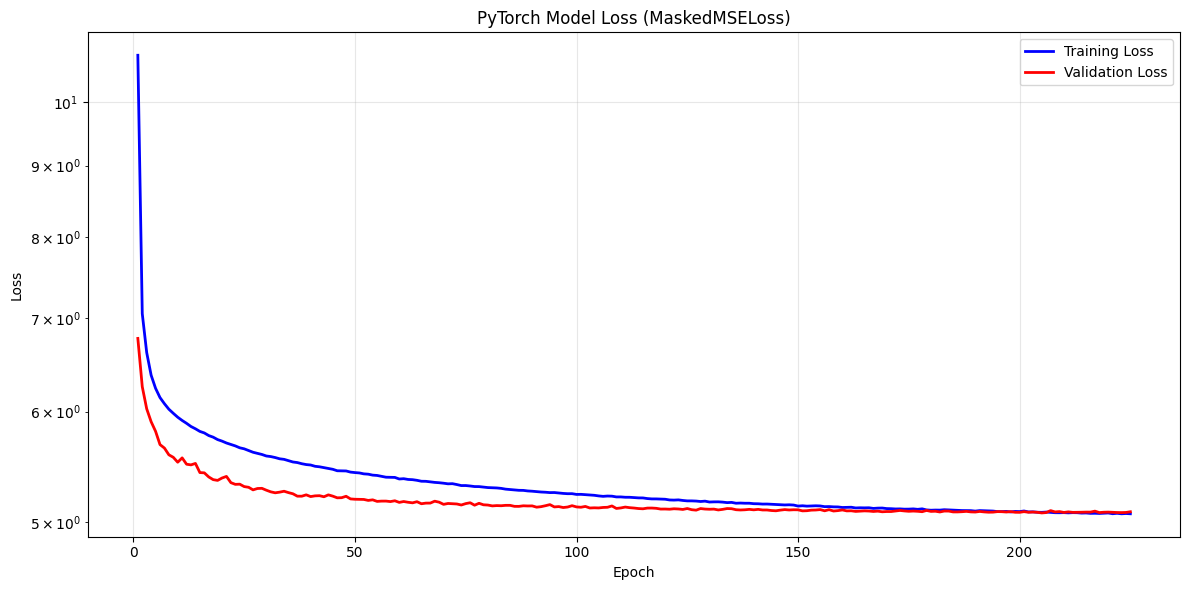


📊 Final PyTorch Training Results:
   Final training loss (MaskedMSE): 5.068829
   Final validation loss (MaskedMSE): 5.085680
   Best validation loss: 5.075850
   ✅ Good generalization (val/train loss ratio: 1.00)

🎯 PyTorch model ready for evaluation!


In [28]:
# 🚀 Train Surrogate Model (PyTorch)
# Training setup: Adam optimizer, MaskedMSELoss, batch_size=128, epochs=250

import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader, TensorDataset

print("🚀 Training PyTorch surrogate model...")

# =============================================================================
# ⚙️ Training Configuration
# =============================================================================

# Training parameters
BATCH_SIZE = 128  # Smaller batch size as requested (64-128)
EPOCHS = 250
VALIDATION_SPLIT = 0.2  # Use 20% of training data for validation

print(f"⚙️ Training configuration:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Validation split: {VALIDATION_SPLIT}")
print(f"   Optimizer: Adam (lr=1e-3)")
print(f"   Loss function: MaskedMSELoss on log-transformed Y")

# =============================================================================
# 📊 Prepare Data for PyTorch
# =============================================================================

if 'model' not in globals():
    print("❌ Model not defined!")
    print("   Make sure to run cell 9 first!")
elif 'X_train' not in globals() or 'Y_train' not in globals():
    print("❌ Training data not found!")
    print("   Make sure to run cell 5 (train-test split) first!")
else:
    print(f"\n📊 Preparing PyTorch datasets...")
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    Y_train_tensor = torch.FloatTensor(Y_train).to(device)
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    Y_test_tensor = torch.FloatTensor(Y_test).to(device)
    
    # Split training data for validation
    n_train = len(X_train_tensor)
    n_val = int(n_train * VALIDATION_SPLIT)
    
    # Create validation split
    indices = torch.randperm(n_train)
    train_indices = indices[n_val:]
    val_indices = indices[:n_val]
    
    X_train_split = X_train_tensor[train_indices]
    Y_train_split = Y_train_tensor[train_indices]
    X_val = X_train_tensor[val_indices]
    Y_val = Y_train_tensor[val_indices]
    
    # Create DataLoaders
    train_dataset = TensorDataset(X_train_split, Y_train_split)
    val_dataset = TensorDataset(X_val, Y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"   Training samples: {len(X_train_split):,}")
    print(f"   Validation samples: {len(X_val):,}")
    print(f"   Test samples: {len(X_test_tensor):,}")
    print(f"   Features: {X_train_split.shape[1]} → {Y_train_split.shape[1]}")

    # =============================================================================
    # 🎯 Training Loop
    # =============================================================================
    
    print(f"\n🎯 Starting PyTorch training...")
    
    # Training history
    train_losses = []
    val_losses = []
    
    # Early stopping parameters
    best_val_loss = float('inf')
    patience = 20
    patience_counter = 0
    
    # Record start time
    start_time = time.time()
    
    for epoch in range(EPOCHS):
        # Training phase
        model.train()
        train_loss = 0.0
        train_batches = 0
        
        for batch_X, batch_Y in train_loader:
            optimizer.zero_grad()
            
            # Forward pass
            pred_Y = model(batch_X)
            loss = criterion(pred_Y, batch_Y)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_batches += 1
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for batch_X, batch_Y in val_loader:
                pred_Y = model(batch_X)
                loss = criterion(pred_Y, batch_Y)
                val_loss += loss.item()
                val_batches += 1
        
        # Calculate average losses
        avg_train_loss = train_loss / train_batches
        avg_val_loss = val_loss / val_batches
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")
        
        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # Save best model
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            # Restore best model
            model.load_state_dict(best_model_state)
            break
    
    # Record end time
    end_time = time.time()
    training_time = end_time - start_time
    
    print(f"\n✅ PyTorch training completed!")
    print(f"   Training time: {training_time/60:.1f} minutes")
    print(f"   Final epoch: {len(train_losses)}")
    print(f"   Best validation loss: {best_val_loss:.6f}")

    # =============================================================================
    # 📈 Plot Training History
    # =============================================================================
    
    print(f"\n📈 Plotting training history...")
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Plot loss
    epochs_range = range(1, len(train_losses) + 1)
    ax.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax.set_title('PyTorch Model Loss (MaskedMSELoss)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')  # Log scale for better visualization
    
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # 📊 Training Summary
    # =============================================================================
    
    final_train_loss = train_losses[-1]
    final_val_loss = val_losses[-1]
    
    print(f"\n📊 Final PyTorch Training Results:")
    print(f"   Final training loss (MaskedMSE): {final_train_loss:.6f}")
    print(f"   Final validation loss (MaskedMSE): {final_val_loss:.6f}")
    print(f"   Best validation loss: {best_val_loss:.6f}")
    
    # Check for overfitting
    overfit_ratio = final_val_loss / final_train_loss
    if overfit_ratio > 1.5:
        print(f"   ⚠️ Potential overfitting detected (val/train loss ratio: {overfit_ratio:.2f})")
    else:
        print(f"   ✅ Good generalization (val/train loss ratio: {overfit_ratio:.2f})")
    
    print(f"\n🎯 PyTorch model ready for evaluation!")

📊 Evaluating PyTorch surrogate model performance...
🔮 Generating predictions on test set...
   Test samples: 26,460
   Prediction shape: (26460, 1692)
   Expected shape: (26460, 1692)
   Y data already in log scale (no denormalization needed)
   Y_test range: [-13.815511, 2.200103]
   Y_pred range: [-18.035658, 11.525002]

📈 Computing test metrics on log-scale Y...

📊 TEST PERFORMANCE METRICS (Log-Scale Y)
🎯 Primary Metrics:
   Test MSE:  10.241357
   Test MAE:  2.304481
   Test R²:   0.096688
   Test RMSE: 3.200212

📊 Data Statistics:
   Y_test  - Mean: -8.519904, Std: 4.306308
   Y_pred  - Mean: -8.625454, Std: 3.221746

📈 Creating prediction visualizations...


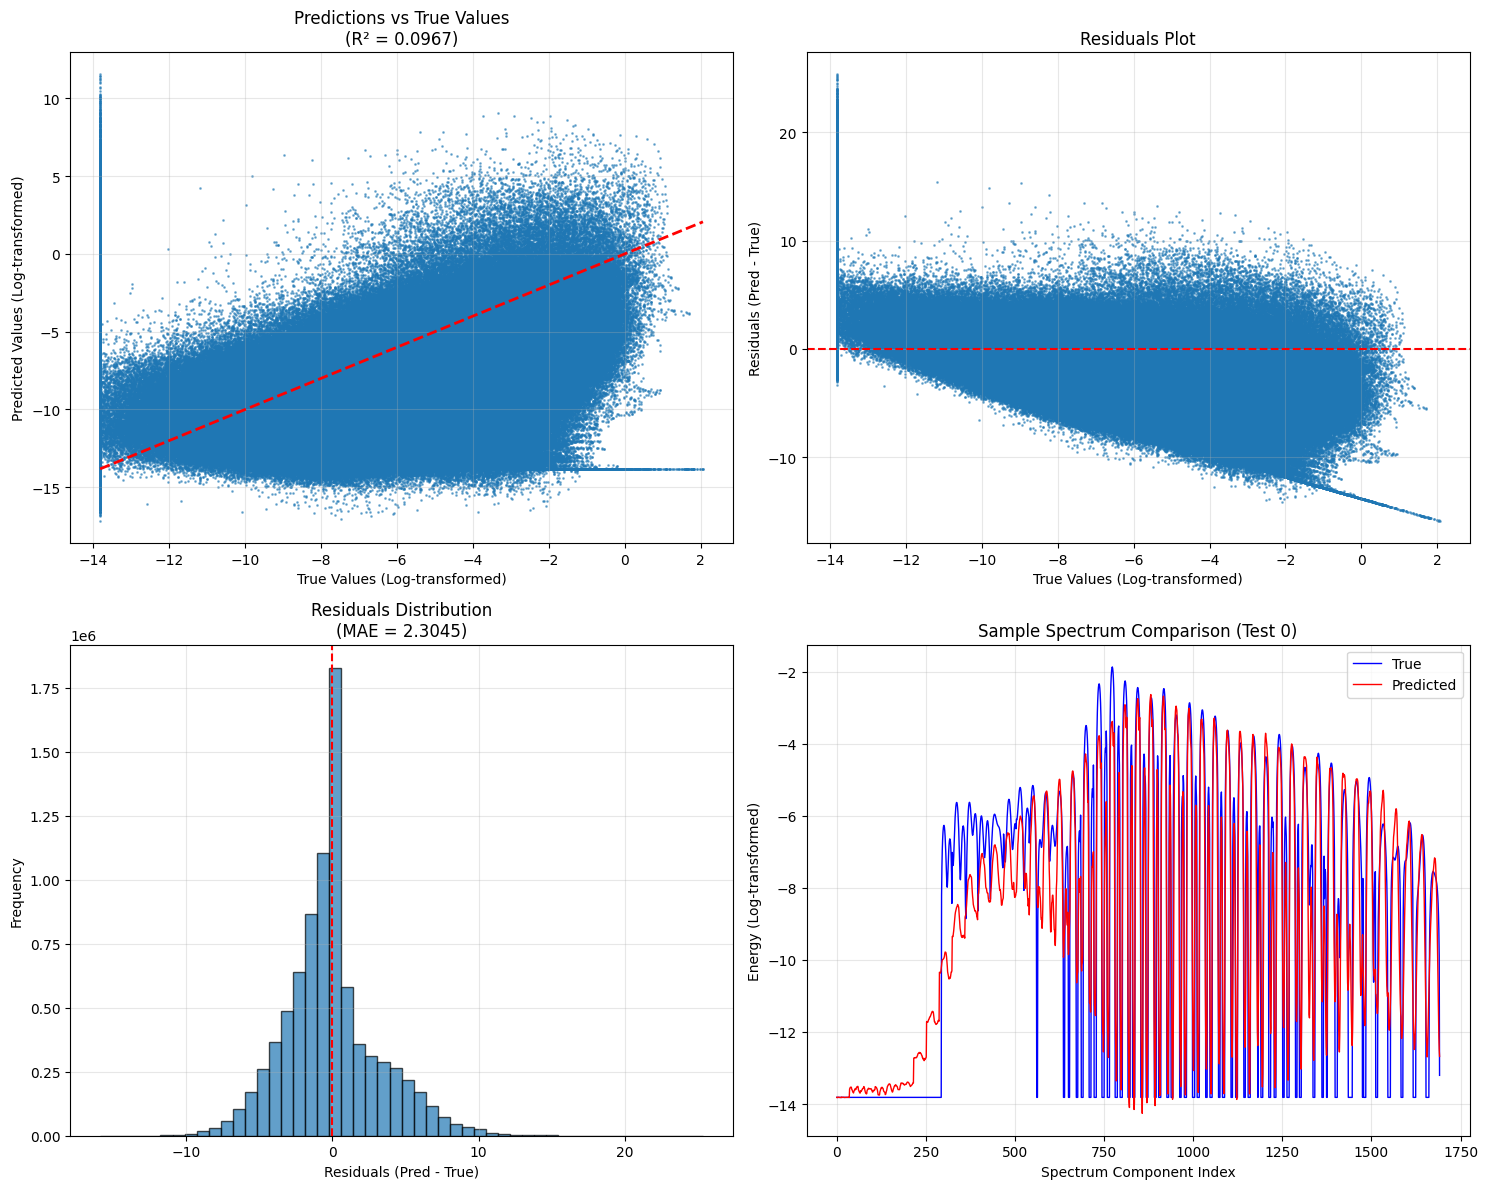


🏆 PERFORMANCE ASSESSMENT
⚠️ Overall Performance: Needs Improvement
   R² Score: 0.0967 (Poor)
   MSE: 10.241357
   MAE: 2.304481
   RMSE: 3.200212

📋 PyTorch Model Summary:
   Test samples: 26,460
   Training samples: 84,672
   Parameters: 428,060
   Architecture: 8 → 256 → 512 → 128 → 1692
   Loss function: MaskedMSELoss
   Transform: log(Y + 1e-6) only (no standardization)
   Performance on log-transformed energy: R² = 0.0967
   The PyTorch surrogate model can predict 2D wave spectra from meteorological data

✅ PyTorch model evaluation completed!


In [29]:
# Compute test MSE, MAE, and R² on log-transformed Y

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import torch

print("📊 Evaluating PyTorch surrogate model performance...")

# =============================================================================
# 🔮 Generate Test Predictions
# =============================================================================

if 'model' not in globals():
    print("❌ Trained model not found!")
    print("   Make sure to run cells 11 and 12 first!")
elif 'X_test_tensor' not in globals() or 'Y_test_tensor' not in globals():
    print("❌ Test data tensors not found!")
    print("   Make sure to run cell 12 (PyTorch training) first!")
else:
    print(f"🔮 Generating predictions on test set...")
    print(f"   Test samples: {X_test_tensor.shape[0]:,}")
    
    # Generate predictions using PyTorch model
    model.eval()
    with torch.no_grad():
        Y_test_pred_tensor = model(X_test_tensor)
    
    # Convert tensors back to numpy for evaluation
    Y_test_log = Y_test_tensor.cpu().numpy()
    Y_test_pred_log = Y_test_pred_tensor.cpu().numpy()
    
    print(f"   Prediction shape: {Y_test_pred_log.shape}")
    print(f"   Expected shape: {Y_test_log.shape}")
    print(f"   Y data already in log scale (no denormalization needed)")
    print(f"   Y_test range: [{Y_test_log.min():.6f}, {Y_test_log.max():.6f}]")
    print(f"   Y_pred range: [{Y_test_pred_log.min():.6f}, {Y_test_pred_log.max():.6f}]")
    
    # =============================================================================
    # 📈 Compute Test Metrics
    # =============================================================================
    
    print(f"\n📈 Computing test metrics on log-scale Y...")
    
    # Compute metrics on log-transformed data
    test_mse = mean_squared_error(Y_test_log, Y_test_pred_log)
    test_mae = mean_absolute_error(Y_test_log, Y_test_pred_log)
    test_r2 = r2_score(Y_test_log, Y_test_pred_log)
    
    # Additional metrics
    test_rmse = np.sqrt(test_mse)
    
    # Statistics on log-scale data
    y_test_mean = np.mean(Y_test_log)
    y_test_std = np.std(Y_test_log)
    y_pred_mean = np.mean(Y_test_pred_log)
    y_pred_std = np.std(Y_test_pred_log)
    
    print(f"\n📊 TEST PERFORMANCE METRICS (Log-Scale Y)")
    print(f"="*60)
    print(f"🎯 Primary Metrics:")
    print(f"   Test MSE:  {test_mse:.6f}")
    print(f"   Test MAE:  {test_mae:.6f}")
    print(f"   Test R²:   {test_r2:.6f}")
    print(f"   Test RMSE: {test_rmse:.6f}")
    
    print(f"\n📊 Data Statistics:")
    print(f"   Y_test  - Mean: {y_test_mean:.6f}, Std: {y_test_std:.6f}")
    print(f"   Y_pred  - Mean: {y_pred_mean:.6f}, Std: {y_pred_std:.6f}")
    
    # =============================================================================
    # 📈 Visualization: Predictions vs True Values
    # =============================================================================
    
    print(f"\n📈 Creating prediction visualizations...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Scatter plot: Predicted vs True (sample of points for clarity)
    n_sample = min(5000, len(Y_test_log))  # Sample for visualization
    sample_idx = np.random.choice(len(Y_test_log), n_sample, replace=False)
    
    y_true_sample = Y_test_log[sample_idx].flatten()
    y_pred_sample = Y_test_pred_log[sample_idx].flatten()
    
    axes[0,0].scatter(y_true_sample, y_pred_sample, alpha=0.5, s=1)
    axes[0,0].plot([y_true_sample.min(), y_true_sample.max()], 
                   [y_true_sample.min(), y_true_sample.max()], 'r--', lw=2)
    axes[0,0].set_xlabel('True Values (Log-transformed)')
    axes[0,0].set_ylabel('Predicted Values (Log-transformed)')
    axes[0,0].set_title(f'Predictions vs True Values\n(R² = {test_r2:.4f})')
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Residuals plot
    residuals = y_pred_sample - y_true_sample
    axes[0,1].scatter(y_true_sample, residuals, alpha=0.5, s=1)
    axes[0,1].axhline(y=0, color='r', linestyle='--')
    axes[0,1].set_xlabel('True Values (Log-transformed)')
    axes[0,1].set_ylabel('Residuals (Pred - True)')
    axes[0,1].set_title('Residuals Plot')
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Histogram of residuals
    axes[1,0].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
    axes[1,0].axvline(x=0, color='r', linestyle='--')
    axes[1,0].set_xlabel('Residuals (Pred - True)')
    axes[1,0].set_ylabel('Frequency')
    axes[1,0].set_title(f'Residuals Distribution\n(MAE = {test_mae:.4f})')
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Sample spectrum comparison (show first test sample)
    sample_idx = 0
    if 'spectrum_columns' in globals() and len(spectrum_columns) == Y_test_log.shape[1]:
        # Extract frequency information for x-axis (simplified)
        x_positions = range(Y_test_log.shape[1])
        axes[1,1].plot(x_positions, Y_test_log[sample_idx], 'b-', label='True', linewidth=1)
        axes[1,1].plot(x_positions, Y_test_pred_log[sample_idx], 'r-', label='Predicted', linewidth=1)
        axes[1,1].set_xlabel('Spectrum Component Index')
        axes[1,1].set_ylabel('Energy (Log-transformed)')
        axes[1,1].set_title(f'Sample Spectrum Comparison (Test {sample_idx})')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
    else:
        # Alternative: show mean spectrum
        axes[1,1].plot(Y_test_log.mean(axis=0), 'b-', label='True (Mean)', linewidth=2)
        axes[1,1].plot(Y_test_pred_log.mean(axis=0), 'r-', label='Predicted (Mean)', linewidth=2)
        axes[1,1].set_xlabel('Spectrum Component Index')
        axes[1,1].set_ylabel('Energy (Log-transformed)')
        axes[1,1].set_title('Mean Spectrum Comparison')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # 🏆 Performance Assessment
    # =============================================================================
    
    print(f"\n🏆 PERFORMANCE ASSESSMENT")
    print(f"="*60)
    
    if test_r2 > 0.9:
        performance = "Excellent"
        emoji = "🏆"
    elif test_r2 > 0.8:
        performance = "Very Good"
        emoji = "🥈"
    elif test_r2 > 0.7:
        performance = "Good"
        emoji = "🥉"
    elif test_r2 > 0.5:
        performance = "Acceptable"
        emoji = "👍"
    else:
        performance = "Needs Improvement"
        emoji = "⚠️"
    
    print(f"{emoji} Overall Performance: {performance}")
    print(f"   R² Score: {test_r2:.4f} ({'Excellent' if test_r2 > 0.9 else 'Good' if test_r2 > 0.8 else 'Acceptable' if test_r2 > 0.7 else 'Poor'})")
    print(f"   MSE: {test_mse:.6f}")
    print(f"   MAE: {test_mae:.6f}")
    print(f"   RMSE: {test_rmse:.6f}")
    
    print(f"\n📋 PyTorch Model Summary:")
    print(f"   Test samples: {X_test_tensor.shape[0]:,}")
    print(f"   Training samples: {X_train_split.shape[0]:,}")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"   Architecture: 8 → 256 → 512 → 128 → 1692")
    print(f"   Loss function: MaskedMSELoss")
    print(f"   Transform: log(Y + 1e-6) only (no standardization)")
    print(f"   Performance on log-transformed energy: R² = {test_r2:.4f}")
    print(f"   The PyTorch surrogate model can predict 2D wave spectra from meteorological data")
    
    print(f"\n✅ PyTorch model evaluation completed!")